In [4]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("matches.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [7]:
df.head(3)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [8]:
df = df.drop(columns=['umpire1','umpire2','method','result_margin','match_type','id'])

In [9]:
df.isnull().sum()

,0
season,0
city,51
date,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0
winner,5


In [10]:
imputer = SimpleImputer(strategy='most_frequent')
df['city'] = imputer.fit_transform(df[['city']]).ravel()
df['winner'] = imputer.fit_transform(df[['winner']]).ravel()
df['player_of_match'] = imputer.fit_transform(df[['player_of_match']]).ravel()


In [11]:
df.isnull().sum()

,0
season,0
city,0
date,0
player_of_match,0
venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0
winner,0


In [12]:
imputer_2 = SimpleImputer(strategy='mean')
df['target_runs'] = imputer_2.fit_transform(df[['target_runs']])
df['target_overs'] = imputer_2.fit_transform(df[['target_overs']])


In [13]:
df.isnull().sum()

,0
season,0
city,0
date,0
player_of_match,0
venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0
winner,0


In [14]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [15]:
df = df.drop(columns=['date'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           1095 non-null   object 
 1   city             1095 non-null   object 
 2   player_of_match  1095 non-null   object 
 3   venue            1095 non-null   object 
 4   team1            1095 non-null   object 
 5   team2            1095 non-null   object 
 6   toss_winner      1095 non-null   object 
 7   toss_decision    1095 non-null   object 
 8   winner           1095 non-null   object 
 9   result           1095 non-null   object 
 10  target_runs      1095 non-null   float64
 11  target_overs     1095 non-null   float64
 12  super_over       1095 non-null   object 
 13  year             1095 non-null   int32  
 14  month            1095 non-null   int32  
 15  day              1095 non-null   int32  
dtypes: float64(2), int32(3), object(11)
memory usage: 124.2+ KB


In [17]:
df.head(2)

,season,city,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,target_runs,target_overs,super_over,year,month,day
0,2007/08,Bangalore,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,223.0,20.0,N,2008,4,18
1,2007/08,Chandigarh,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,241.0,20.0,N,2008,4,19


In [18]:
df['winner'].value_counts()

,count
winner,
Mumbai Indians,149
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bangalore,116
Rajasthan Royals,112
Sunrisers Hyderabad,88
Kings XI Punjab,88
Delhi Daredevils,67
Delhi Capitals,48


In [19]:
df['player_of_match'].value_counts().sort_values(ascending=False)

,count
player_of_match,
AB de Villiers,30
CH Gayle,22
RG Sharma,19
DA Warner,18
V Kohli,18
...,...
DR Sams,1
KS Bharat,1
Shashank Singh,1


In [20]:
df['season'].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [21]:
df[(df['season'] == '2009') & (df['winner'] == 'Mumbai Indians')]

,season,city,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,target_runs,target_overs,super_over,year,month,day
58,2009,Cape Town,SR Tendulkar,Newlands,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,field,Mumbai Indians,runs,166.0,20.0,N,2009,4,18
72,2009,Port Elizabeth,SR Tendulkar,St George's Park,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,bat,Mumbai Indians,runs,188.0,20.0,N,2009,4,27
78,2009,East London,JP Duminy,Buffalo Park,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,bat,Mumbai Indians,runs,149.0,20.0,N,2009,5,1
93,2009,Port Elizabeth,JP Duminy,St George's Park,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,bat,Mumbai Indians,runs,158.0,20.0,N,2009,5,10
97,2009,Centurion,Harbhajan Singh,SuperSport Park,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,bat,Mumbai Indians,wickets,120.0,20.0,N,2009,5,12


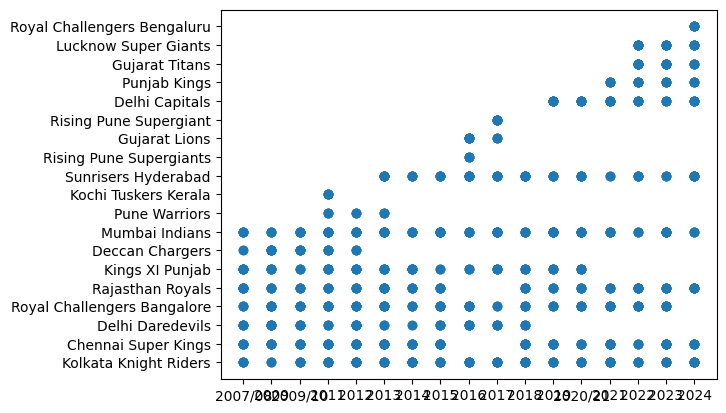

In [22]:
plt.scatter(df['season'],df['winner'])
plt.show()

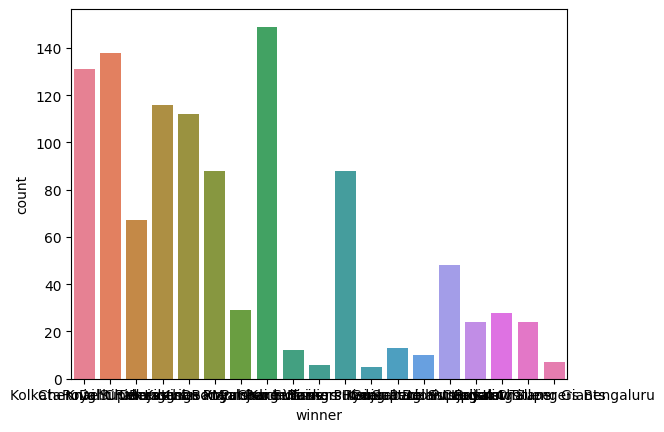

In [24]:
sns.countplot(x='winner',hue='winner',data=df)
plt.show()

In [30]:
df.head(2)

,season,city,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,target_runs,target_overs,super_over,year,month,day
0,2007/08,Bangalore,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,223.0,20.0,N,2008,4,18
1,2007/08,Chandigarh,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,241.0,20.0,N,2008,4,19


In [33]:
df['season'].value_counts().sort_values(ascending=False)

,count
season,
2013,76
2022,74
2012,74
2023,74
2011,73
2024,71
2019,60
2016,60
2009/10,60


In [34]:
df['year'].value_counts().sort_values(ascending=False)

,count
year,
2013,76
2022,74
2012,74
2023,74
2011,73
2024,71
2019,60
2016,60
2010,60


In [38]:
df['team1'].nunique()
df['team1'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [41]:
df['winner'].value_counts().sort_values(ascending=False)

,count
winner,
Mumbai Indians,149
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bangalore,116
Rajasthan Royals,112
Sunrisers Hyderabad,88
Kings XI Punjab,88
Delhi Daredevils,67
Delhi Capitals,48


In [45]:
df['player_of_match'].value_counts().sort_values(ascending=False)

,count
player_of_match,
AB de Villiers,30
CH Gayle,22
RG Sharma,19
DA Warner,18
V Kohli,18
...,...
DR Sams,1
KS Bharat,1
Shashank Singh,1


In [48]:
df['venue'].nunique()

58

In [46]:
df['venue'].value_counts().sort_values(ascending=False)

,count
venue,
Eden Gardens,77
Wankhede Stadium,73
M Chinnaswamy Stadium,65
Feroz Shah Kotla,60
"Rajiv Gandhi International Stadium, Uppal",49
"MA Chidambaram Stadium, Chepauk",48
Sawai Mansingh Stadium,47
Dubai International Cricket Stadium,46
"Wankhede Stadium, Mumbai",45


In [49]:
df.head()

,season,city,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,target_runs,target_overs,super_over,year,month,day
0,2007/08,Bangalore,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,223.0,20.0,N,2008,4,18
1,2007/08,Chandigarh,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,241.0,20.0,N,2008,4,19
2,2007/08,Delhi,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,130.0,20.0,N,2008,4,19
3,2007/08,Mumbai,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,166.0,20.0,N,2008,4,20
4,2007/08,Kolkata,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,111.0,20.0,N,2008,4,20


In [54]:
X =(df['result'] == 'runs').value_counts()

In [56]:
X

,count
result,
False,597
True,498


In [63]:
df['toss_decision'].max()

'field'

In [64]:
df['toss_winner'].max()

'Sunrisers Hyderabad'

In [75]:
X = df[df["toss_winner"] != df["winner"]]

In [76]:
X

,season,city,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,target_runs,target_overs,super_over,year,month,day
0,2007/08,Bangalore,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,223.0,20.0,N,2008,4,18
2,2007/08,Delhi,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,130.0,20.0,N,2008,4,19
3,2007/08,Mumbai,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,166.0,20.0,N,2008,4,20
4,2007/08,Kolkata,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,111.0,20.0,N,2008,4,20
5,2007/08,Jaipur,SR Watson,Sawai Mansingh Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,bat,Rajasthan Royals,wickets,167.0,20.0,N,2008,4,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,2024,Bengaluru,F du Plessis,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Chennai Super Kings,Chennai Super Kings,field,Royal Challengers Bengaluru,runs,219.0,20.0,N,2024,5,18
1090,2024,Hyderabad,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,215.0,20.0,N,2024,5,19
1091,2024,Ahmedabad,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,160.0,20.0,N,2024,5,21
1093,2024,Chennai,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,176.0,20.0,N,2024,5,24
